In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 6
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 2
plt.rcParams['ytick.major.size'] = 2
%config InlineBackend.figure_format='retina'

import sys
from pathlib import Path
sys.path.append('../')
from utils import *  # key functions for this project

THRESHOLD = 50


# Initial analysis (no smoothing)

In [10]:
from matplotlib.colors import LogNorm

temporal_thr_arr = np.array([1, 2, 5, 10, 20, 50, 100, 200, 500])  # seconds
dt_arr = np.array([0.02, 0.04, 0.1, 0.2, 0.5, 1, 2, 5, 10, 30, 60, 120])
noise_arr = [0, 10, 20, 50]

def run_spatiotemporal_thresholding(t_under_threshold, loops, actual_means, cmap):
    t_under_threshold = t_under_threshold[t_under_threshold['noise'].isin(noise_arr)]

    # mean duration of the under-threshold events lasting at least temporal_thr, for each (temporal_thr, loop, noise, dt)
    mean_lifetimes = pd.concat({temporal_thr: t_under_threshold[t_under_threshold['time'] >= temporal_thr]
                                              .groupby(['loop', 'noise', 'dt'])['time'].mean()
                                for temporal_thr in temporal_thr_arr}, names=['temporal_thr']).unstack('dt')
    norm = LogNorm(vmin=np.nanmin(mean_lifetimes.values), vmax=np.nanmax(mean_lifetimes.values))

    return mean_lifetimes

def plot_spatiotemporal_thresholding(t_under_threshold, loops, actual_means, cmap):
    t_under_threshold = t_under_threshold[t_under_threshold['noise'].isin(noise_arr)]

    # mean duration of the under-threshold events lasting at least temporal_thr, for each (temporal_thr, loop, noise, dt)
    mean_lifetimes = pd.concat({temporal_thr: t_under_threshold[t_under_threshold['time'] >= temporal_thr]
                                              .groupby(['loop', 'noise', 'dt'])['time'].mean()
                                for temporal_thr in temporal_thr_arr}, names=['temporal_thr']).unstack('dt')
    norm = LogNorm(vmin=np.nanmin(mean_lifetimes.values), vmax=np.nanmax(mean_lifetimes.values))

    fig, axs = plt.subplots(len(noise_arr), len(loops), figsize=(6, 5.5), sharex=True, sharey=True, layout='constrained')
    for row, noise in enumerate(noise_arr):
        for col, loop_num in enumerate(loops):
            ax = axs[row, col]
            grid = (mean_lifetimes.xs((loop_num, noise), level=('loop', 'noise'))
                    .reindex(index=temporal_thr_arr, columns=dt_arr))
            mesh = ax.pcolormesh(grid.to_numpy(), cmap=cmap, norm=norm, edgecolor='white', linewidth=0.3)
            ax.set_facecolor('#cccccc')  # cells with no events left after temporal thresholding
            ax.tick_params(length=0)
            if row == 0:
                ax.set_title(f'loop {loop_num} (actual mean {actual_means[loop_num]:.3g} s)')
            if col == 0:
                ax.set_ylabel(f'noise = {noise} nm\ntemporal threshold [s]')
            if row == len(noise_arr) - 1:
                ax.set_xlabel('time between frames [s]')

    axs[0, 0].set_xticks(np.arange(len(dt_arr)) + 0.5, [f'{dt:g}' for dt in dt_arr])
    axs[0, 0].set_yticks(np.arange(len(temporal_thr_arr)) + 0.5, [f'{thr:g}' for thr in temporal_thr_arr])
    for ax in axs[-1]:
        ax.tick_params(axis='x', labelrotation=90)

    fig.colorbar(mesh, ax=axs, label='mean lifetime inferred [s]', shrink=0.4, aspect=25)
    fig.legend([Rectangle((0, 0), 1, 1, facecolor='#cccccc')], ['no events ≥ temporal threshold'],
               loc='outside lower right', frameon=False)
    return fig, axs

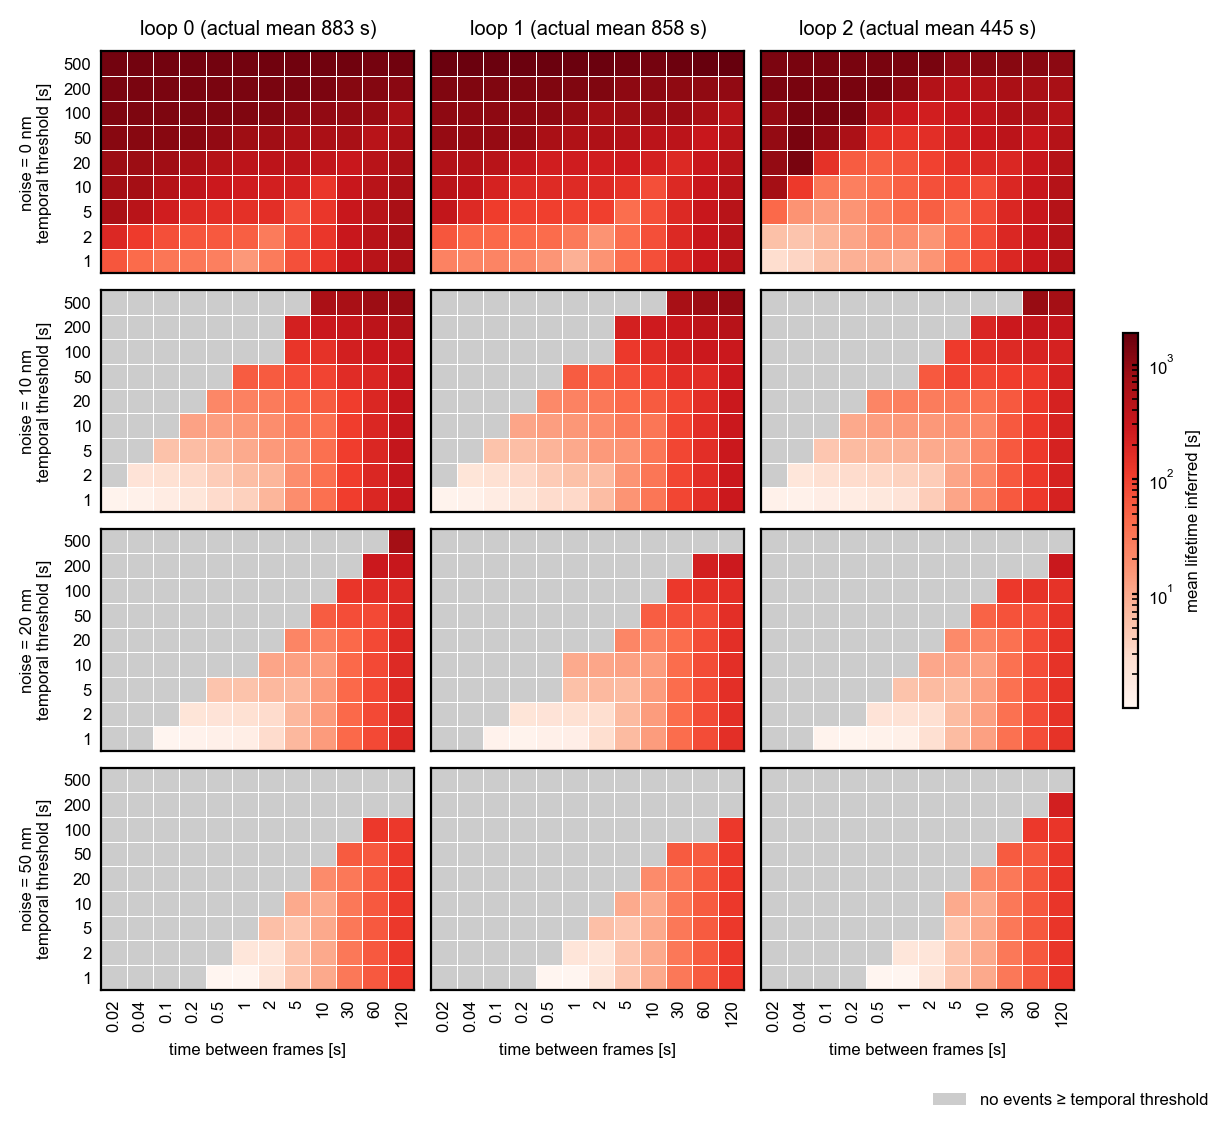

In [5]:
CTCF_loop_lifetimes = pd.read_csv(f'../data/CTCF_loops_lifetimes.csv')
t_under_50nm_CTCF = pd.read_csv(f'../data/CTCF_loops_under_threshold_times_50nm.csv')

CTCF_loops = [0, 1, 2]
CTCF_actual_means = CTCF_loop_lifetimes.groupby('loop')['lifetime'].mean()

fig, axs = plot_spatiotemporal_thresholding(t_under_50nm_CTCF, CTCF_loops, CTCF_actual_means, 'Reds')
plt.savefig('../figure_exports/fig2_CTCF_spatiotemporal_thresholding.svg')

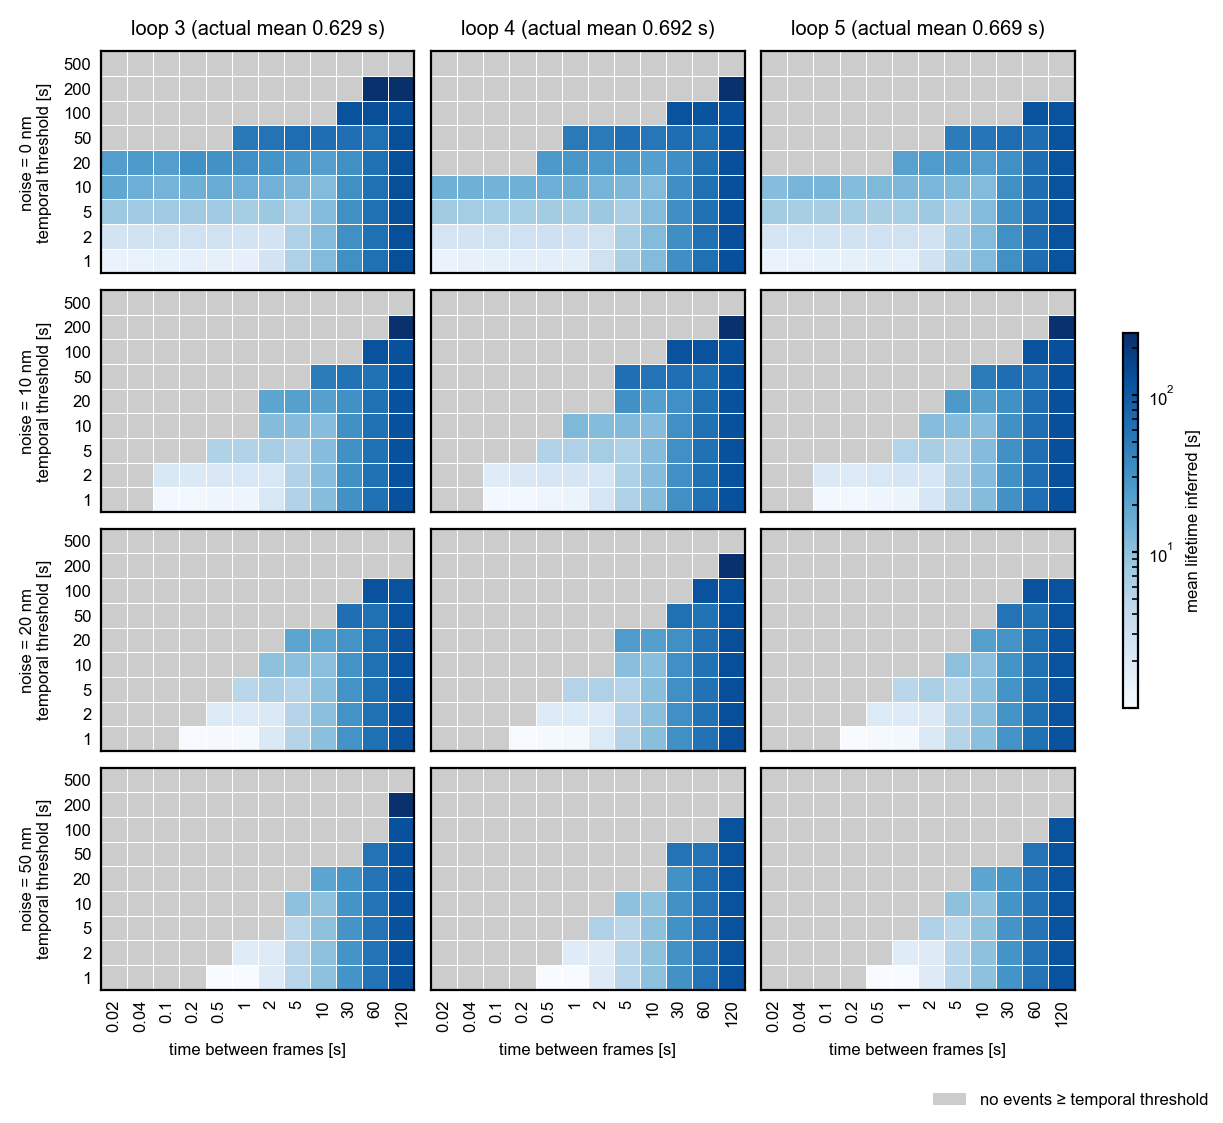

In [6]:
EP_loops_lifetime_histograms = pd.read_pickle('../data/EP_loops_lifetime_histograms.pkl')
t_under_50nm_EP = pd.read_csv(f'../data/EP_loops_under_threshold_times_50nm.csv')

EP_loops = [3, 4, 5]
EP_actual_means = EP_loops_lifetime_histograms['mean']

fig, axs = plot_spatiotemporal_thresholding(t_under_50nm_EP, EP_loops, EP_actual_means, 'Blues')
plt.savefig('../figure_exports/fig2_EP_spatiotemporal_thresholding.svg')

In [7]:
from scipy.optimize import curve_fit

# power law in the two axis variables, fit in log space (both axes are log-spaced and the lifetimes span decades):
# mean lifetime inferred = A * dt^a * temporal_thr^b
def log_mean_lifetime(log_x, log_A, a, b):
    log_dt, log_temporal_thr = log_x
    return log_A + a * log_dt + b * log_temporal_thr

def R2_spatiotemporal_thresholding(mean_lifetimes, loops):
    log_dt, log_temporal_thr = np.meshgrid(np.log10(dt_arr), np.log10(temporal_thr_arr))
    R2 = pd.DataFrame(index=loops, columns=noise_arr, dtype=float)
    for loop_num in loops:
        for noise in noise_arr:
            grid = (mean_lifetimes.xs((loop_num, noise), level=('loop', 'noise'))
                    .reindex(index=temporal_thr_arr, columns=dt_arr))
            log_lifetime = np.log10(grid.to_numpy())
            ok = np.isfinite(log_lifetime)  # skip the cells with no events left after temporal thresholding
            popt, _ = curve_fit(log_mean_lifetime, (log_dt[ok], log_temporal_thr[ok]), log_lifetime[ok])
            residuals = log_lifetime[ok] - log_mean_lifetime((log_dt[ok], log_temporal_thr[ok]), *popt)
            R2.loc[loop_num, noise] = 1 - np.sum(residuals**2) / np.sum((log_lifetime[ok] - np.mean(log_lifetime[ok]))**2)
    return R2

def plot_R2_heatmap(R2, cmap, title):
    vmin, vmax = 0.6, 1

    fig, ax = plt.subplots(figsize=(2.2, 1.5), layout='constrained')
    mesh = ax.pcolormesh(R2.to_numpy(), cmap=cmap, vmin=vmin, vmax=vmax, edgecolor='white', linewidth=0.3)
    for row, loop_num in enumerate(R2.index):
        for col, noise in enumerate(R2.columns):
            ax.text(col + 0.5, row + 0.5, f'{R2.loc[loop_num, noise]:.2f}', ha='center', va='center',
                    color='white' if R2.loc[loop_num, noise] > (vmin + vmax)/2 else 'black')
    ax.invert_yaxis()  # first loop on top

    ax.set_xticks(np.arange(len(R2.columns)) + 0.5, [f'{noise:g}' for noise in R2.columns])
    ax.set_yticks(np.arange(len(R2.index)) + 0.5, [f'{loop_num:g}' for loop_num in R2.index])
    ax.tick_params(length=0)
    ax.set_xlabel('noise [nm]')
    ax.set_ylabel('loop')
    ax.set_title(title)

    fig.colorbar(mesh, ax=ax, label='$R^2$')
    return fig, ax

/tmp/ipykernel_2814813/2312770505.py:1: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.1)
  from scipy.optimize import curve_fit


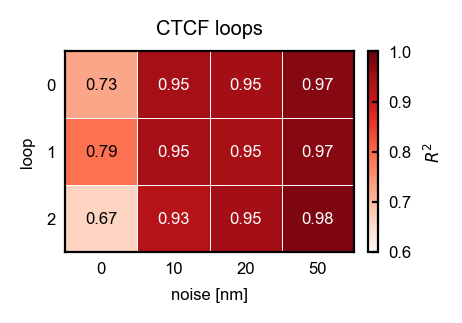

In [8]:
CTCF_mean_lifetimes = run_spatiotemporal_thresholding(t_under_50nm_CTCF, CTCF_loops, CTCF_actual_means, 'Reds')
CTCF_R2 = R2_spatiotemporal_thresholding(CTCF_mean_lifetimes, CTCF_loops)

fig, ax = plot_R2_heatmap(CTCF_R2, 'Reds', 'CTCF loops')
plt.savefig('../figure_exports/fig2_CTCF_spatiotemporal_thresholding_R2.svg')

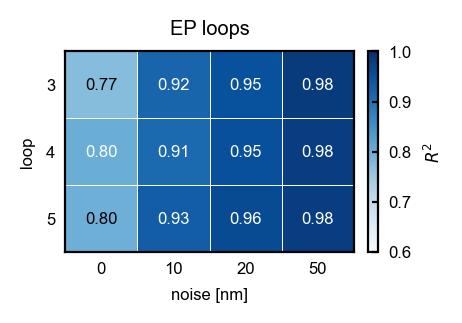

In [9]:
EP_mean_lifetimes = run_spatiotemporal_thresholding(t_under_50nm_EP, EP_loops, EP_actual_means, 'Blues')
EP_R2 = R2_spatiotemporal_thresholding(EP_mean_lifetimes, EP_loops)

fig, ax = plot_R2_heatmap(EP_R2, 'Blues', 'EP loops')
plt.savefig('../figure_exports/fig2_EP_spatiotemporal_thresholding_R2.svg')

# Spatiotemporal thresholding with smoothing

In [181]:
def apply_temporal_threshold(binary_arr, temporal_threshold):
    '''Given a binary array, filters out events that are shorter than a specified number of frames.'''
    filtered_arr = binary_arr.copy()
    padded_arr = np.r_[0, binary_arr, 0]
    interval_starts = np.where(np.diff(padded_arr) == 1)[0]
    interval_ends = np.where(np.diff(padded_arr) == -1)[0]

    for start, end in zip(interval_starts, interval_ends):
        if end - start < temporal_threshold:
            filtered_arr[start:end] = 0

    return filtered_arr


def apply_moving_average(binary_arr, window_size):
    '''Given a binary array, apply smoothing by using a moving average with the provided window size in frames.'''
    return np.convolve(binary_arr, np.ones(window_size) / window_size, mode='same')


def under_threshold_times_spatiotemporal_method(
    loop_num: int,
    rep: int,
    noise: int,
    non_sticky: bool = False,
    target_frame_duration: float = 1,
    threshold: float = 50,
    temporal_threshold: float = 180,
) -> pd.Series:
    """
    Get the event lifetimes using the spatiotemporal filtering method. target_frame_duration and temporal_threshold are in seconds
    """

    sample_every = int(np.round(target_frame_duration / DELTA_T))
    actual_frame_duration = sample_every * DELTA_T
    temporal_threshold_frames = int(np.round(temporal_threshold / actual_frame_duration))
    
    traj = load_trajectory(loop_num, rep, noise, non_sticky)[::sample_every]

    binary_array = np.array((traj < threshold) * 1)
    binary_array_filtered = apply_temporal_threshold(binary_array, temporal_threshold_frames)
    binary_array_smoothed = apply_moving_average(binary_array_filtered, temporal_threshold_frames)
    binary_array_final = (binary_array_smoothed>0.5) * 1
    binary_array_final = pd.Series(binary_array_final, index=traj.index)

    return event_lifetimes(binary_array_final, ignore_changes_time=0, dt=actual_frame_duration)


def under_threshold_times_spatiotemporal_method_all_reps(
    loop_num: int,
    noise: int,
    non_sticky: bool = False,
    target_frame_duration: float = 1,
    threshold: float = 50,
    temporal_threshold: float = 180,
    pbar: tqdm | None = None,
    reps: np.ndarray | None = None
) -> np.ndarray:
    """
    Get the event lifetimes using the spatiotemporal filtering method, for all reps of a loop.
    target_frame_duration and temporal_threshold are in seconds
    """

    lifetimes_all: list[pd.Series] = []
    
    if reps is None:
        reps = range(10, 19 + 1)  # 10..19 inclusive

    for rep in reps:
        lifetimes_this_rep = under_threshold_times_spatiotemporal_method(
            loop_num,
            rep,
            noise,
            non_sticky,
            target_frame_duration,
            threshold,
            temporal_threshold
        )
        lifetimes_all.append(lifetimes_this_rep)

        if pbar is not None:
            pbar.update(1)

    if not lifetimes_all:
        return np.array([], dtype=float)

    lifetimes = pd.concat(lifetimes_all)
    return lifetimes.to_numpy()


In [ ]:
THRESHOLD = 200

dt_arr = np.array([0.02, 0.04, 0.1, 0.2, 0.5, 1, 2, 5, 10, 30, 60, 120])
loop_num_arr = np.array([0, 1, 2, 3, 4, 5])
noise_arr = np.array([0, 10, 20, 50])
temporal_threshold_arr = np.array([1, 2, 5, 10, 20, 50, 100, 200, 500])

n_reps = 19 - 10 + 1  # 10..19 inclusive
total_iters = len(dt_arr) * len(loop_num_arr) * len(noise_arr) * len(temporal_threshold_arr) * n_reps

rows = []

with tqdm(total=total_iters, desc="calculating times below threshold", unit="rep") as pbar:
    for dt in dt_arr:
        for loop_num in loop_num_arr:
            for noise in noise_arr:
                for temporal_threshold in temporal_threshold_arr:
                    under_threshold_times = under_threshold_times_spatiotemporal_method_all_reps(loop_num, noise, non_sticky=False,
                                                                                                 target_frame_duration=dt,
                                                                                                 threshold=THRESHOLD,
                                                                                                 temporal_threshold=temporal_threshold,
                                                                                                 pbar=pbar)
                    for under_threshold_time in under_threshold_times:
                        rows.append(
                            {
                                "loop": loop_num,
                                "noise": noise,
                                "dt": dt,
                                "threshold": THRESHOLD,
                                "temporal_threshold": temporal_threshold,
                                "time": under_threshold_time,
                            }
                        )

under_threshold_times_df = pd.DataFrame(rows)

under_threshold_times_df.to_csv(f'../data/all_loops_under_threshold_times_spatiotemporal.csv', index=False, float_format="%.2f")


calculating times below threshold:   0%|          | 0/25920 [00:00<?, ?rep/s]

KeyboardInterrupt: 

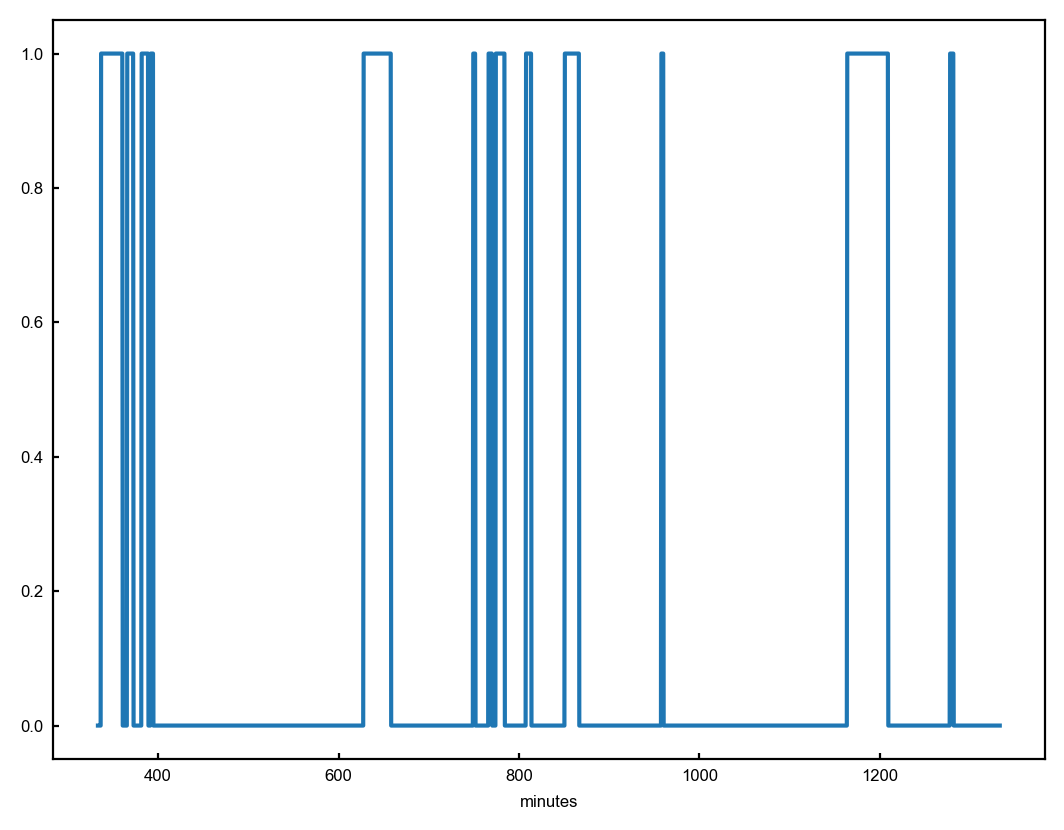

In [179]:
loop_num = 0
rep = 15
noise = 30

target_frame_duration = 30
temporal_threshold = 180
threshold = 200

sample_every = int(np.round(target_frame_duration / DELTA_T))
actual_frame_duration = sample_every * DELTA_T
temporal_threshold_frames = int(np.round(temporal_threshold / actual_frame_duration))

traj = load_trajectory(loop_num, rep, noise, False)[::sample_every]

binary_array = np.array((traj < threshold) * 1)
binary_array_filtered = apply_temporal_threshold(binary_array, temporal_threshold_frames)
binary_array_smoothed = apply_moving_average(binary_array_filtered, temporal_threshold_frames)
binary_array_final = (binary_array_smoothed>0.5) * 1
binary_array_final = pd.Series(binary_array_final, index=traj.index)

plt.plot(binary_array_final.index/60, binary_array_final)
plt.xlabel('minutes');


In [ ]:
np.mean(under_threshold_times_spatiotemporal_method(loop_num, rep, noise, False, target_frame_duration, threshold, temporal_threshold))

np.float64(750.0)